Libraries loaded.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int

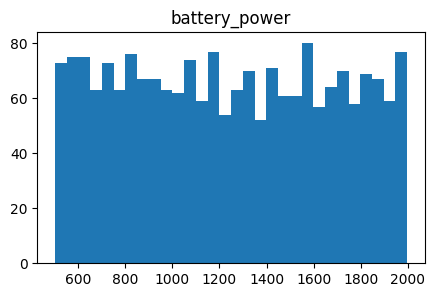

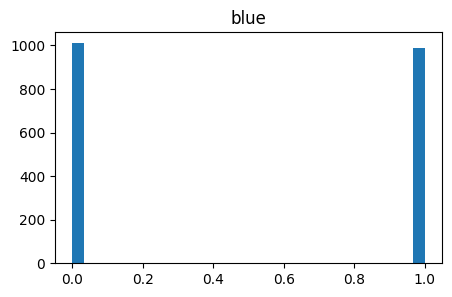

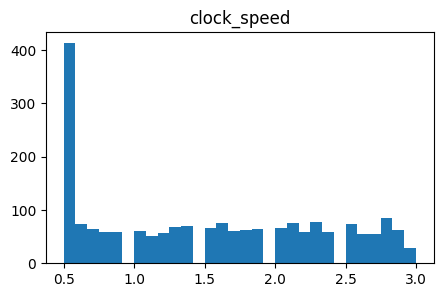

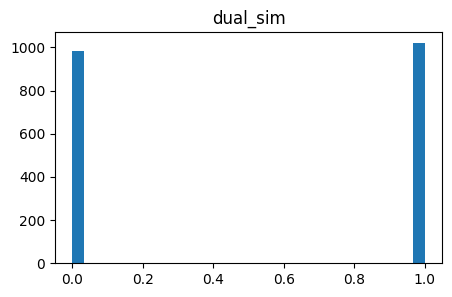

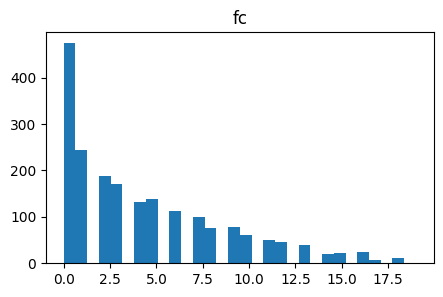

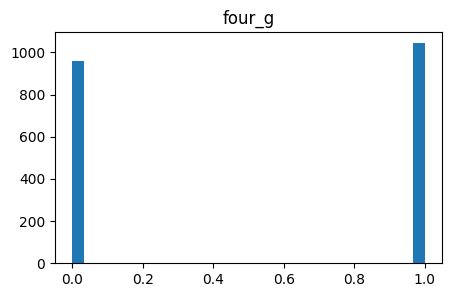

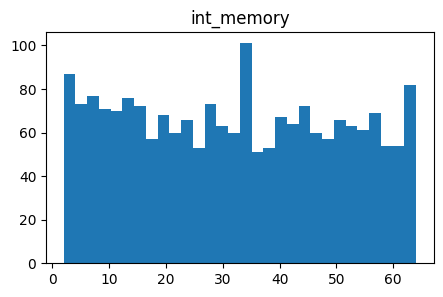

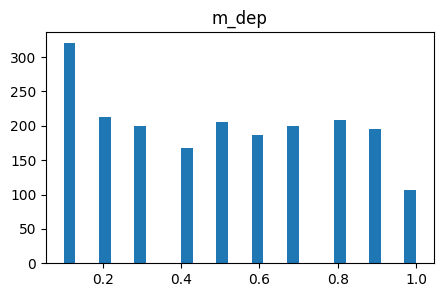

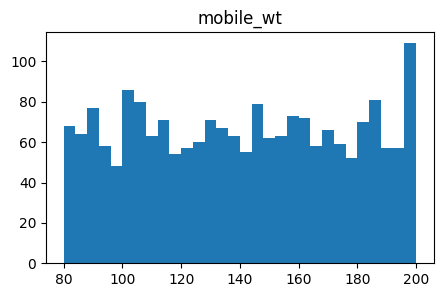

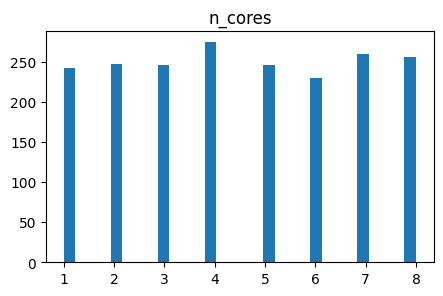

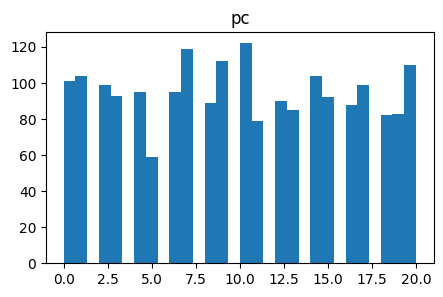

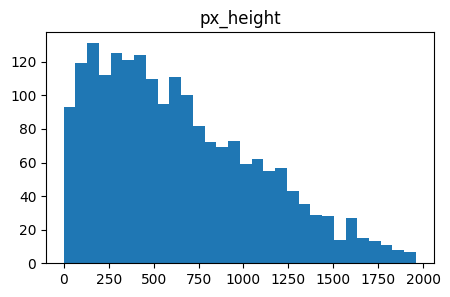

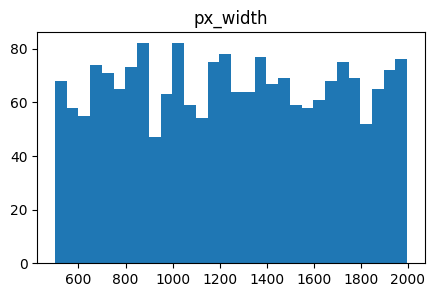

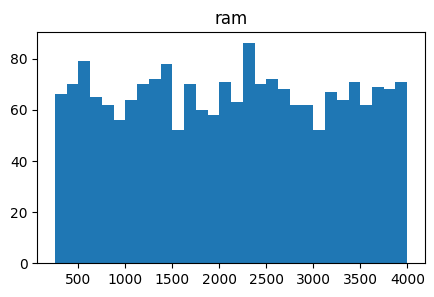

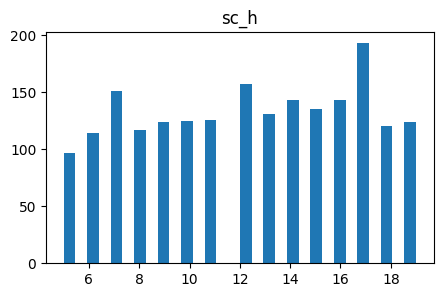

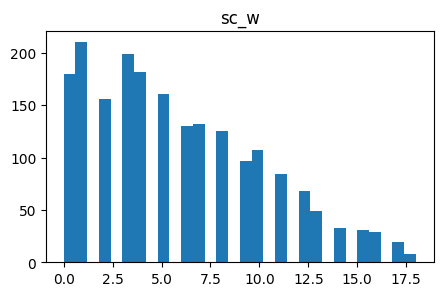

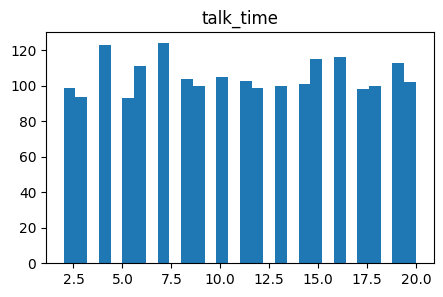

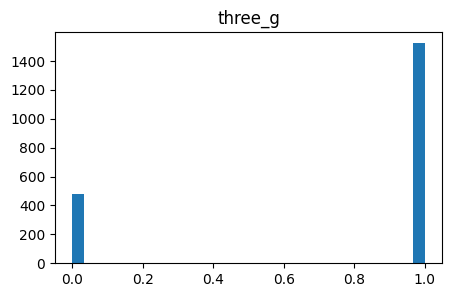

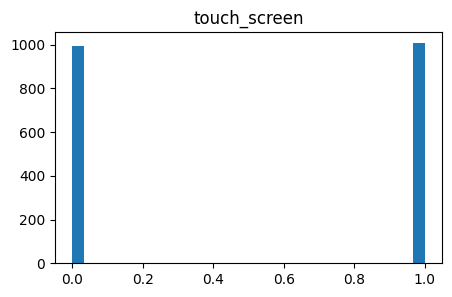

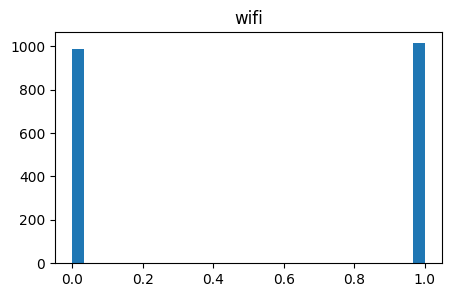

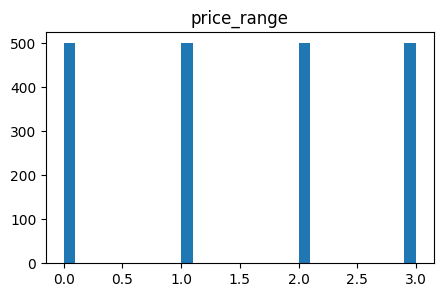

TypeError: OneHotEncoder.__init__() got an unexpected keyword argument 'sparse'

In [2]:
# Step-by-step Python notebook code for train.csv

import math
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype, is_object_dtype
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
import joblib

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

print("Libraries loaded.")

csv_path = r"C:\Users\dell\Downloads\train.csv"
df = pd.read_csv(csv_path)


df = pd.read_csv(csv_path)
df.head()

df.info()

df.describe(include='all')

missing = df.isnull().sum().sort_values(ascending=False)
missing

numeric_cols = [c for c in df.columns if is_numeric_dtype(df[c])]
categorical_cols = [c for c in df.columns if is_object_dtype(df[c])]

numeric_cols, categorical_cols

target = "price_range"
df[target].value_counts()

for col in numeric_cols:
    plt.figure(figsize=(5,3))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)
    plt.show()

X = df.drop(columns=[target])
y = df[target]

num_cols = numeric_cols.copy()
cat_cols = categorical_cols.copy()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='__missing__')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

model = RandomForestClassifier(n_estimators=100, random_state=42)

clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('model', model)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

joblib.dump(clf, '/mnt/data/trained_pipeline.joblib')
